# 01 — EDA y criterios de perfiles de eficiencia — EnergiAI (Bloque B)

Este notebook explora el dataset simulado de consumo eléctrico (Bloque A) y sustenta,
con evidencia visual, los **criterios de clasificación** de perfiles energéticos
(*Eficiente*, *Moderado*, *Ineficiente*) definidos y justificados en
[`docs/criterios_perfiles.md`](../docs/criterios_perfiles.md).

La fórmula del índice de eficiencia y sus umbrales viven en
[`src/labeling_rules.py`](../src/labeling_rules.py), única fuente de verdad del etiquetado.

**Estructura:** 1) Carga y descripción · 2) Distribuciones univariadas ·
3) Análisis bivariado · 4) Correlación · 5) Outliers · 6) Balance de clases · 7) Conclusiones.

## 1. Carga y descripción del dataset

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.2f}")

# Paleta consistente por categoría (semaforo de eficiencia) para todo el notebook.
ORDEN_CAT = ["Eficiente", "Moderado", "Ineficiente"]
PALETA_CAT = {"Eficiente": "#22c55e", "Moderado": "#eab308", "Ineficiente": "#ef4444"}

# La ruta funciona tanto si el notebook se corre desde notebooks/ como desde la raiz.
CANDIDATOS = [Path("../data/dataset_energia.csv"), Path("data-science/data/dataset_energia.csv")]
RUTA_CSV = next(p for p in CANDIDATOS if p.exists())
df = pd.read_csv(RUTA_CSV)
df["categoria"] = pd.Categorical(df["categoria"], categories=ORDEN_CAT, ordered=True)
print(f"Dataset: {RUTA_CSV}  |  filas: {len(df)}  |  columnas: {df.shape[1]}")
df.head()

Dataset: ../data/dataset_energia.csv  |  filas: 4000  |  columnas: 6


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,202.54,False,2,Departamento,12,Ineficiente
1,225.13,True,6,Casa,7,Eficiente
2,920.43,True,13,Local,10,Ineficiente
3,218.95,False,5,Departamento,7,Moderado
4,170.40,False,8,Casa,6,Eficiente


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   consumo_kwh         4000 non-null   float64 
 1   uso_horario_pico    4000 non-null   bool    
 2   cantidad_equipos    4000 non-null   int64   
 3   tipo_inmueble       4000 non-null   str     
 4   horas_alto_consumo  4000 non-null   int64   
 5   categoria           4000 non-null   category
dtypes: bool(1), category(1), float64(1), int64(2), str(1)
memory usage: 133.1 KB


In [3]:
# Resumen estadistico de las variables numericas
df.describe()

,consumo_kwh,cantidad_equipos,horas_alto_consumo
count,4000.00,4000.00,4000.00
mean,369.13,8.77,7.53
std,253.95,4.10,3.28
min,31.97,1.00,1.00
25%,224.18,6.00,5.00
50%,310.09,8.00,8.00
75%,440.88,11.00,10.00
max,3734.24,30.00,12.00


In [4]:
# Resumen de las variables categoricas / booleanas
df.describe(include=["object", "bool", "category"])

/tmp/ipykernel_33201/3535525263.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "bool", "category"])


,uso_horario_pico,tipo_inmueble,categoria
count,4000,4000,4000
unique,2,3,3
top,False,Casa,Ineficiente
freq,2083,1816,1399


In [5]:
# Verificacion de calidad: nulos y duplicados
print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Nulos por columna:
consumo_kwh           0
uso_horario_pico      0
cantidad_equipos      0
tipo_inmueble         0
horas_alto_consumo    0
categoria             0
dtype: int64

Filas duplicadas: 0


El dataset tiene **4.000 registros**, las **6 columnas del Contrato 3**, **sin nulos**.
Los tipos son los esperados: `consumo_kwh` float, `uso_horario_pico` bool,
`cantidad_equipos` y `horas_alto_consumo` enteros, `tipo_inmueble` y `categoria` texto.
Las pocas filas duplicadas son coincidencias plausibles entre perfiles simulados, no errores de datos.

## 2. Distribuciones univariadas

Antes de relacionar variables, entendemos cómo se distribuye cada una por sí sola.

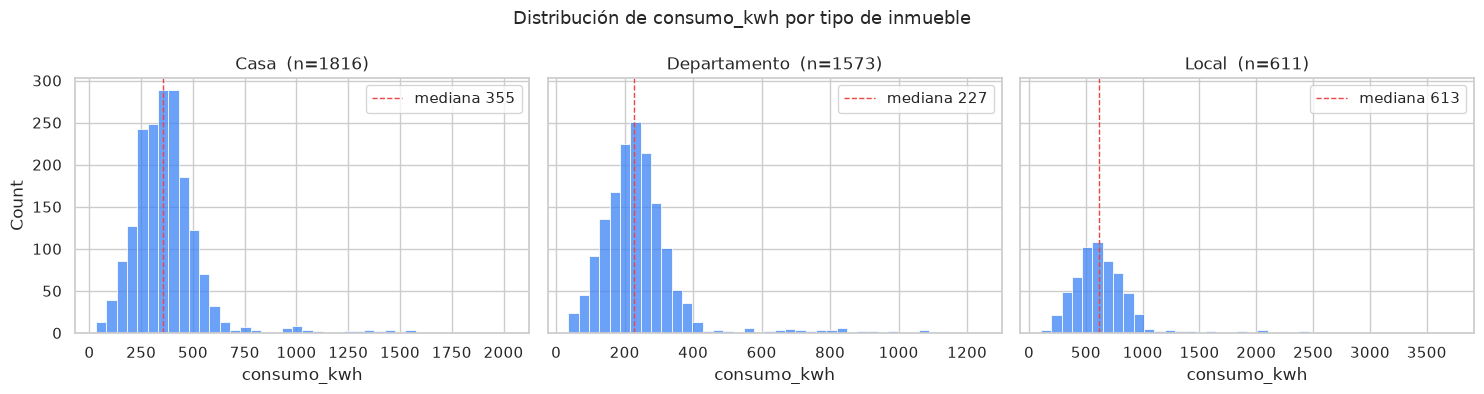

In [6]:
# Histograma de consumo_kwh por tipo de inmueble (cada tipo consume a su escala)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tipo in zip(axes, ["Casa", "Departamento", "Local"]):
    sub = df.loc[df["tipo_inmueble"] == tipo, "consumo_kwh"]
    sns.histplot(sub, bins=40, ax=ax, color="#3b82f6")
    ax.axvline(sub.median(), color="#ef4444", ls="--", lw=1, label=f"mediana {sub.median():.0f}")
    ax.set_title(f"{tipo}  (n={len(sub)})")
    ax.set_xlabel("consumo_kwh")
    ax.legend()
fig.suptitle("Distribución de consumo_kwh por tipo de inmueble", fontsize=13)
plt.tight_layout()
plt.show()

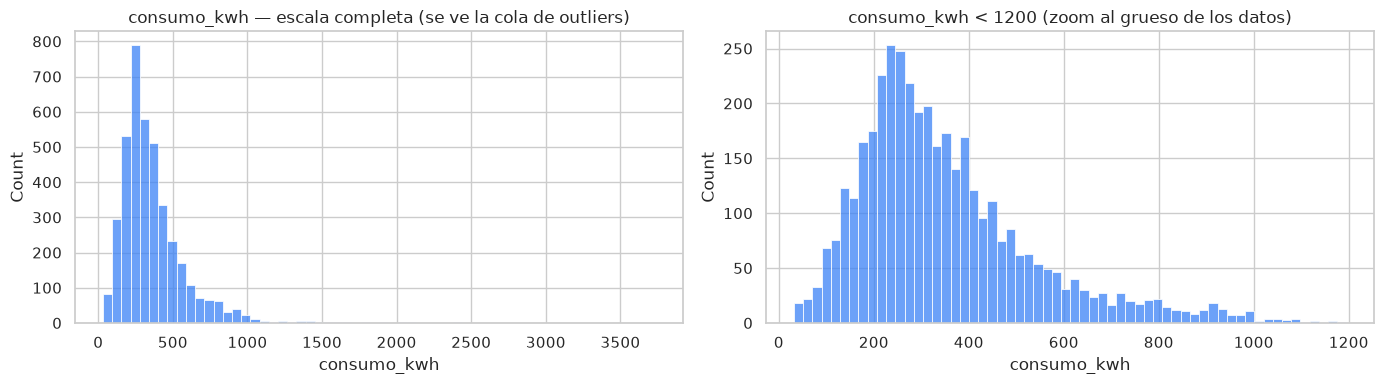

In [7]:
# Distribucion global de consumo_kwh: la cola larga a la derecha son los outliers inyectados
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["consumo_kwh"], bins=60, ax=axes[0], color="#3b82f6")
axes[0].set_title("consumo_kwh — escala completa (se ve la cola de outliers)")
sns.histplot(df.loc[df["consumo_kwh"] < 1200, "consumo_kwh"], bins=60, ax=axes[1], color="#3b82f6")
axes[1].set_title("consumo_kwh < 1200 (zoom al grueso de los datos)")
plt.tight_layout()
plt.show()

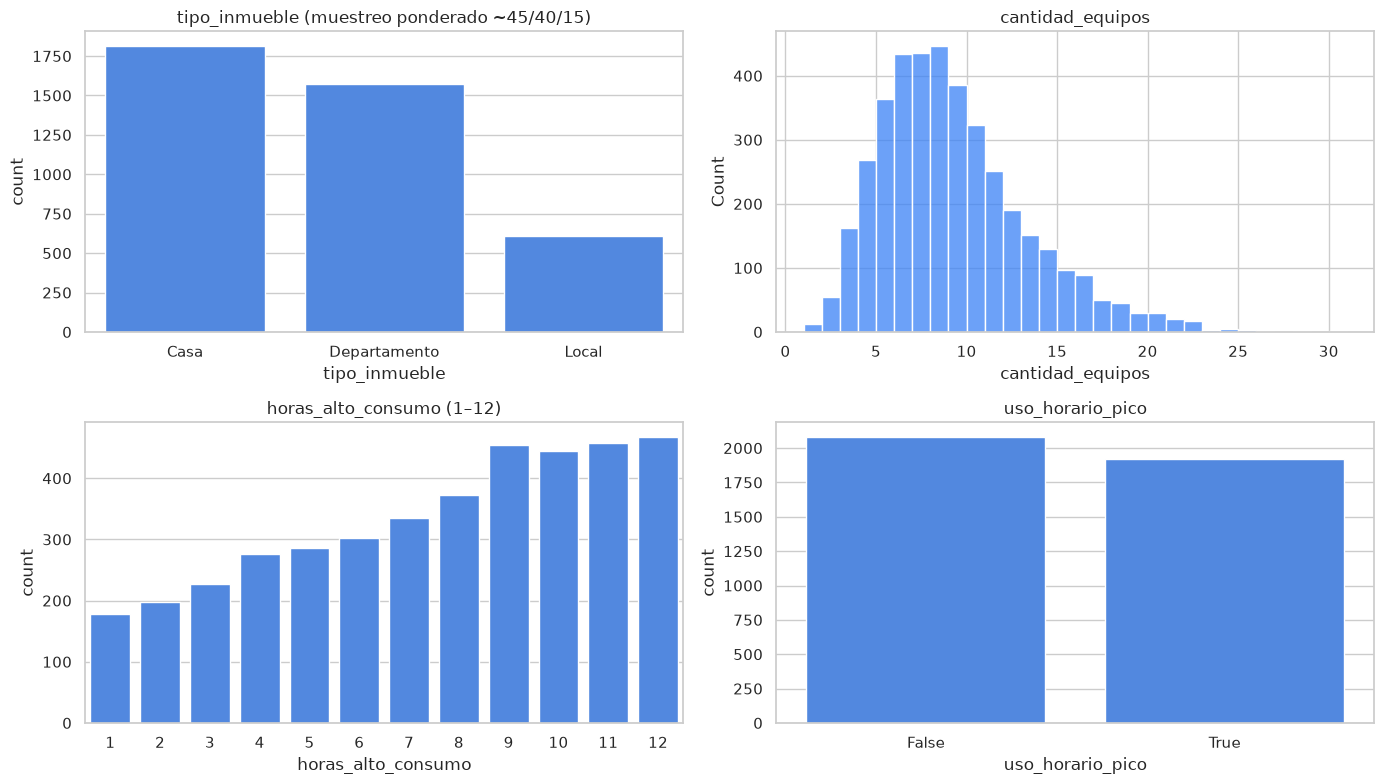

In [8]:
# Distribucion del resto de features de entrada
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.countplot(x="tipo_inmueble", data=df, ax=axes[0, 0],
              order=["Casa", "Departamento", "Local"], color="#3b82f6")
axes[0, 0].set_title("tipo_inmueble (muestreo ponderado ~45/40/15)")

sns.histplot(df["cantidad_equipos"], bins=range(1, df["cantidad_equipos"].max() + 2),
             ax=axes[0, 1], color="#3b82f6")
axes[0, 1].set_title("cantidad_equipos")

sns.countplot(x="horas_alto_consumo", data=df, ax=axes[1, 0], color="#3b82f6")
axes[1, 0].set_title("horas_alto_consumo (1–12)")

sns.countplot(x="uso_horario_pico", data=df, ax=axes[1, 1], color="#3b82f6")
axes[1, 1].set_title("uso_horario_pico")

plt.tight_layout()
plt.show()

**Lo que vemos:**

- `consumo_kwh` tiene una forma aproximadamente normal **dentro de cada tipo**, centrada donde
  se simuló (Casa ~350, Departamento ~220, Local ~600), lo que confirma por qué el índice normaliza
  por tipo en vez de comparar kWh en crudo.
- La distribución global muestra una **cola larga a la derecha**: son los ~4% de outliers inyectados
  a propósito (se analizan en la sección 5).
- `tipo_inmueble` respeta el muestreo ponderado; `cantidad_equipos` y `horas_alto_consumo` cubren
  bien su rango; `uso_horario_pico` queda razonablemente repartido (~48% true).

## 3. Análisis bivariado

Relacionamos cada feature con la categoría para ver qué distingue a un perfil *Ineficiente* de uno *Eficiente* — la base empírica de los criterios.

/tmp/ipykernel_33201/518596378.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="categoria", y="consumo_kwh", data=df, order=ORDEN_CAT,


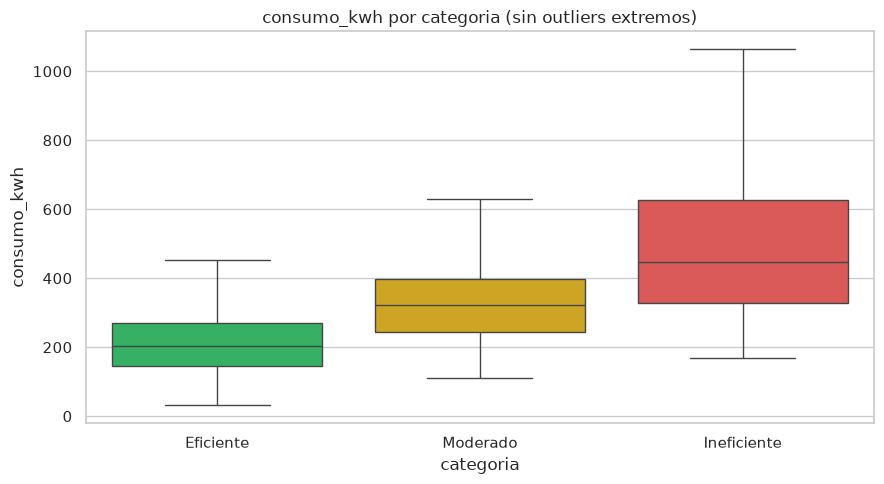

In [9]:
# Consumo por categoria. Se ocultan los outliers extremos (se ven en la seccion 5)
# para no aplastar la escala y poder leer las cajas.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x="categoria", y="consumo_kwh", data=df, order=ORDEN_CAT,
            palette=PALETA_CAT, showfliers=False, ax=ax)
ax.set_title("consumo_kwh por categoria (sin outliers extremos)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_33201/745020311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa.index, y=tasa.values, order=ORDEN_CAT, palette=PALETA_CAT, ax=ax)


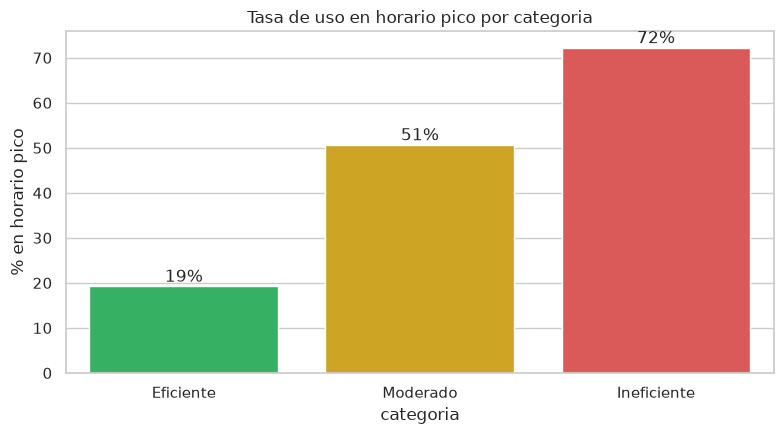

In [10]:
# Tasa de uso en horario pico por categoria
tasa = df.groupby("categoria", observed=True)["uso_horario_pico"].mean() * 100
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=tasa.index, y=tasa.values, order=ORDEN_CAT, palette=PALETA_CAT, ax=ax)
for i, v in enumerate(tasa.reindex(ORDEN_CAT).values):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
ax.set_ylabel("% en horario pico")
ax.set_title("Tasa de uso en horario pico por categoria")
plt.tight_layout()
plt.show()

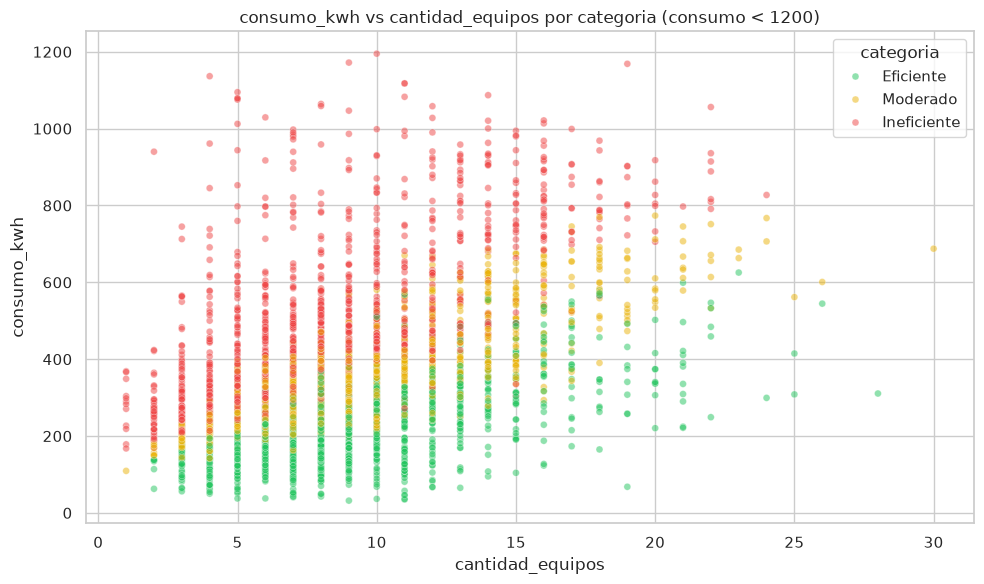

In [11]:
# Consumo vs cantidad de equipos, coloreado por categoria.
# Se acota el eje x a consumos < 1200 kWh para legibilidad (los outliers van aparte).
sub = df[df["consumo_kwh"] < 1200]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x="cantidad_equipos", y="consumo_kwh", hue="categoria",
                hue_order=ORDEN_CAT, palette=PALETA_CAT, data=sub, alpha=0.5, s=25, ax=ax)
ax.set_title("consumo_kwh vs cantidad_equipos por categoria (consumo < 1200)")
ax.legend(title="categoria")
plt.tight_layout()
plt.show()

**Lo que vemos:**

- El **consumo mediano crece de forma clara** de *Eficiente* → *Moderado* → *Ineficiente*: es el separador más fuerte, coherente con el peso 0.50 que le da la fórmula.
- La **tasa de horario pico sube** con la ineficiencia, confirmándolo como señal válida (aunque de menor peso).
- En el scatter, a **igual número de equipos**, los perfiles ineficientes se ubican arriba (más kWh por equipo): justifica el término `consumo_por_equipo`.

## 4. Matriz de correlación

Medimos la relación lineal entre las features numéricas y con la categoría (codificada 0=Eficiente, 1=Moderado, 2=Ineficiente).

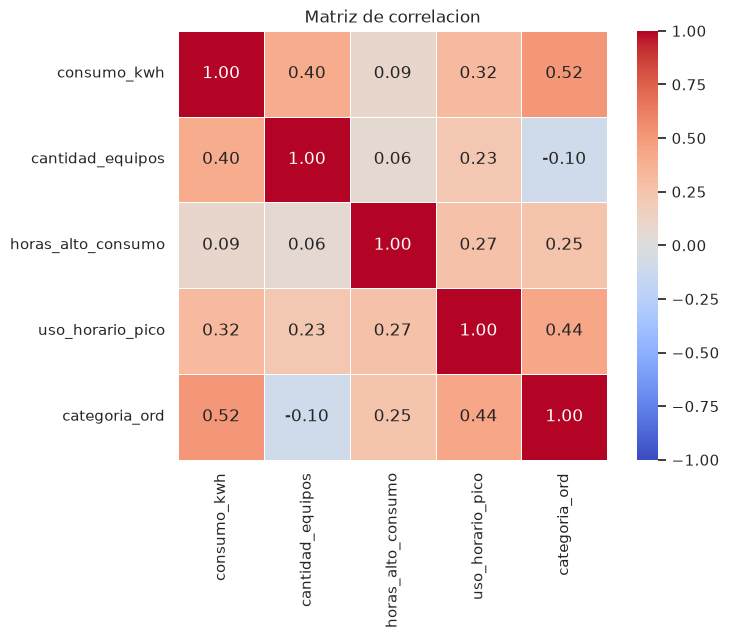

In [12]:
num = df.copy()
num["uso_horario_pico"] = num["uso_horario_pico"].astype(int)
num["categoria_ord"] = num["categoria"].cat.codes  # 0/1/2
cols = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo",
        "uso_horario_pico", "categoria_ord"]
corr = num[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, ax=ax)
ax.set_title("Matriz de correlacion")
plt.tight_layout()
plt.show()

**Lo que vemos:**

- `consumo_kwh` es lo más correlacionado con la categoría — el driver principal.
- `uso_horario_pico` y `horas_alto_consumo` correlacionan positivo pero más débil: agravantes, no causas estructurales.
- `cantidad_equipos` correlaciona **negativo** con la categoría: a más equipos, menor consumo *por equipo*, luego mejor perfil relativo — exactamente lo que modela el índice.
- No hay features redundantes (ninguna pareja con correlación cercana a 1), así que todas aportan información al modelo del Bloque C.